In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path().resolve().parent))
import config
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from src.cleaning import clean
from src.feature_engineering import build_panel_data

from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

#load data
df = pd.read_csv(config.DB_LOCATION)
cleaned, full_history = clean(df)
panel_data, last_complete_year = build_panel_data(cleaned, full_history)


test = panel_data[panel_data["Year"] == 2024]
test_X = test[config.FEATURES]
test_y = test["Churns"]

# generate calibrated probabilities on test set
calibrated_clf = joblib.load(Path().resolve() / "calibrated_model.pkl")
probs = calibrated_clf.predict_proba(test_X)[:, 1]

C:\Users\bnpar\AppData\Local\Temp\ipykernel_35948\4027525280.py:16: DtypeWarning: Columns (33,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(config.DB_LOCATION)


### Decision Framework

The purpose of the model was to identify lifters at risk of churn, to inform who to target with retention interventions. The intervention is chosen to be a half price coaching session if the lifter signs up for membership. This is chosen as it has a low cost to the federation compared to high perceived value from lifters. 


For any individual lifter $i$, a retention intervention should be applied **if the expected value of intervening exceeds the expected value of leaving them alone.**

The expected profit generated by a single lifter with no intervention is:
$$E_{\text{no int}} = (1 - p_i) \cdot V$$

And with intervention (assuming natural stayers still stay, and a portion of expected churners are saved):
$$E_{\text{int}} = [(1 - p_i) + p_i \cdot S] \cdot (V - C)$$

Where:
- $V$ is the membership value of a retained lifter.
- $C$ is the net operational cost of running a half price coaching session.
- $p_i$ is the predicted baseline churn probability for lifter $i$.
- $S$ is the **Save Rate** (the conditional effectiveness of the intervention, i.e., the proportion of true churners saved by the incentive).

An intervention should be offered when $E_{\text{int}} > E_{\text{no int}}$. Setting these equal and solving for $p_i$ gives us the optimal decision threshold $t^*$:
$$t^* = \frac{C}{S \cdot (V - C) + C}$$

If a lifter's predicted churn probability $p_i$ is greater than $t^*$, the expected return of offering the discount is mathematically positive.

In [7]:
# Calculate the optimal threshold algebraically
V = 50                  # financial value of a retained lifter
C = 10                  # cost of retention intervention
save_rate = 0.15        # assumed save rate for true churners
upper_threshold = 1

t_star = C / (save_rate * (V - C) + C)
t_star = round(t_star, 2)
print(f"Optimal decision threshold (t*): {t_star}")

Optimal decision threshold (t*): 0.62


In [9]:

in_window = (probs > t_star) & (probs <= upper_threshold)


baseline_churn = test_y.reset_index(drop=True)[in_window].mean()
mde = 0.05 
alpha = 0.05
power = 0.8
effect = proportion_effectsize(baseline_churn - mde, baseline_churn)
n_per_group = NormalIndPower().solve_power(effect_size=effect, alpha=alpha, power=power)
n_per_group = float(n_per_group[0]) if hasattr(n_per_group, '__len__') else float(n_per_group)

actual_n = int(((probs > t_star) & (probs < upper_threshold)).sum())
print(f'Baseline churn rate above t*: {baseline_churn:.1%}')
print(f'Required control group size: {round(n_per_group):,}')
print(f'Available in intervention band: {actual_n:,}')
print(f'Required control group as % of targeted lifters: {round(n_per_group) / actual_n:.1%}')

Baseline churn rate above t*: 70.2%
Required control group size: 1,370
Available in intervention band: 13,943
Required control group as % of targeted lifters: 9.8%


### Expected profit

In [20]:
n_intervene = in_window.sum()
n_control = round(n_per_group)
n_treatment = n_intervene - n_control

# treatment and control group
rng = np.random.default_rng(42)
control_indices = rng.choice(np.where(in_window)[0], size=n_control, replace=False)
treatment_indices = np.setdiff1d(np.where(in_window)[0], control_indices)

# expected profit from treatment band
probs_treatment = probs[treatment_indices]
expected_retention_treatment = (1 - probs_treatment) + (probs_treatment * save_rate)
profit_intervened = np.sum(expected_retention_treatment * (V - C)) 

# expected profit from people in intervention band in control group
profit_control = np.sum((1 - probs[control_indices]) * V)  

# expected profit from people outside intervention band
profit_not_intervened = np.sum((1 - probs[~in_window]) * V)

total_expected_profit = profit_intervened + profit_control + profit_not_intervened
baseline_no_intervention = np.sum((1 - probs) * V)

print(f'Expected profit with interventions: £{total_expected_profit:,.0f}')
print(f'Expected profit with no interventions: £{baseline_no_intervention:,.0f}')
print(f'Expected profit uplift from baseline: £{total_expected_profit - baseline_no_intervention:,.0f}')

Expected profit with interventions: £1,015,222
Expected profit with no interventions: £997,869
Expected profit uplift from baseline: £17,353


### Profit sensitivity to assumptions/estimations

The section above acknowledges that at best we can use an estimate of the average Save Rate ($S$) for the targeted cohort. It is therefore worth exploring the **sensitivity of profit to the estimation** of the Save Rate. If we use $S = 0.15$, we find  $t^* = 0.62$. Therefore in the plot below, we fix $t^*$ and explore what profit would be for different percentage uptake rates from our at-risk lifters.

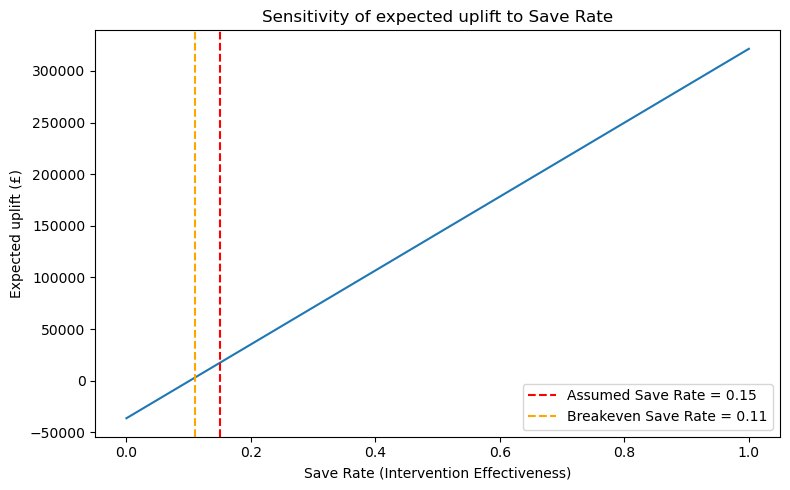

In [23]:
save_rates = np.arange(0, 1.01, 0.01)
uplifts = []

for s in save_rates:
    exp_retention = (1 - probs_treatment) + (probs_treatment * s)
    profit = np.sum(exp_retention * (V - C)) + profit_control + profit_not_intervened
    uplifts.append(profit - baseline_no_intervention)

uplifts = np.array(uplifts)
breakeven = save_rates[np.argmax(uplifts >= 0)]

plt.figure(figsize=(8, 5))
plt.plot(save_rates, uplifts)
plt.axvline(x=save_rate, color='red', linestyle='--', label=f'Assumed Save Rate = {save_rate}')
plt.axvline(x=breakeven, color='orange', linestyle='--', label=f'Breakeven Save Rate = {breakeven:.2f}')
plt.xlabel('Save Rate (Intervention Effectiveness)')
plt.ylabel('Expected uplift (£)')
plt.title('Sensitivity of expected uplift to Save Rate')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
scenarios = {
    'Worst case (S = 0.0)': 0.0,
    'Expected (S = 0.15)': 0.15,
    'Best case (S = 0.25)': 0.25
}

print(f'{"Scenario":<30} {"Expected Uplift":>20}')
print('-' * 52)

for label, s in scenarios.items():
    exp_retention = (1 - probs_treatment) + (probs_treatment * s)
    profit = np.sum(exp_retention * (V - C)) + profit_control + profit_not_intervened
    uplift = profit - baseline_no_intervention
    print(f'{label:<30} £{uplift:>18,.0f}')

Scenario                            Expected Uplift
----------------------------------------------------
Worst case (S = 0.0)           £           -36,303
Expected (S = 0.15)            £            17,353
Best case (S = 0.30)           £            53,124


Using the held-out control group allows for verification of the value of S to inform whether the retention interventions should continue for the following years. 